# Projet Image


In [1]:
from __future__ import division

import math as math
import numpy as np
import scipy as scp
import time
import pylab as pyl
from matplotlib import cm
import matplotlib.pyplot as plt
import scipy.signal as scp
from matplotlib.pyplot import imshow as imageplot
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.image as mpimg
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
%load_ext autoreload
%autoreload 2




Pour ce projet on utiliser les 2 images au format RGB ci dessous

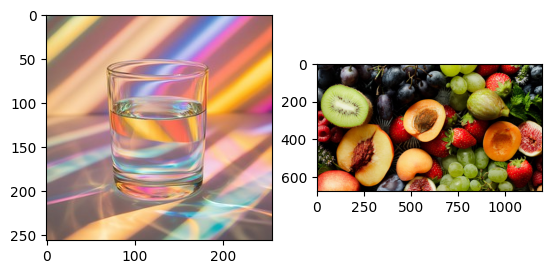

In [2]:
w1 = mpimg.imread("glass.png")[:,:,:3]
w2 = mpimg.imread("test.png")[:,:,:3]
fig,ax=plt.subplots(1,2)
ax[0].imshow(w1)
ax[1].imshow(w2)


Pour implémenter le filtre de Bayer ainsi que son adjoint, on utilise une masque *mask* consistant à une image dans $v \in \mathbb{R}^{3(N\times M)}$ tel que 
$$v_{i,j}=\begin{cases}
(0, 0, 1) & \text{si } i \bmod 2 = 0 \text{ et } j \bmod 2 = 0 \\
(1, 0, 0) & \text{si } i \bmod 2 = 1 \text{ et } j \bmod 2 = 1 \\
(0, 1, 0) & \text{sinon} \quad
\end{cases}$$

Pour diminuer le temps de calcule on gardera le masque global, il faudrat le changer à chaque fois que l'on change d'image pour adapter sa taille.

In [6]:
def bayer(u,adj):
    if adj==0:
        return np.sum(u * mask, axis=2)
    if adj==1:
        return u[:, :, None] * mask

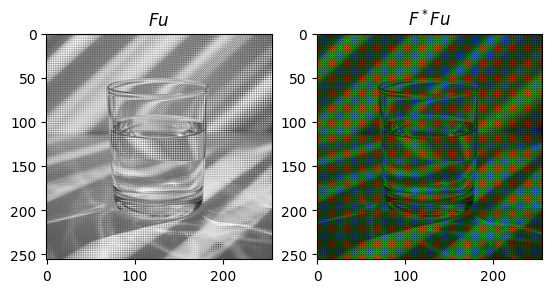

In [7]:
w = mpimg.imread("glass.png")[:,:,:3]
mask = np.zeros(np.shape(w))
mask[1::2, 1::2, 0] = 1.0  
mask[0::2, 0::2, 2] = 1.0  
mask[0::2, 1::2, 1] = 1.0  
mask[1::2, 0::2, 1] = 1.0 

fig,ax=plt.subplots(1,2)
ax[0].imshow(bayer(w,0),cmap="gray")
ax[0].set_title("$Fu$")
ax[1].set_title("$F^*Fu$")
ax[1].imshow(bayer(bayer(w,0),1),cmap="gray") 

In [5]:

def phi(img,beta):
    return np.sqrt(img+beta)

def phi_p(img,beta):
    return np.sqrt(1/(4*(img+beta)))

def bayer(u,adj):
    if adj==0:
        return np.sum(u * mask, axis=2)
    if adj==1:
        return u[:, :, None] * mask

def grad_x(img, adjoint):
    tmp=np.zeros(img.shape)
    if adjoint==0:
        tmp[-1]=img[0]
        tmp[:-1]=img[1:]
    else:
        tmp[0]=img[-1]
        tmp[1:]=img[:-1]
    return tmp-img

def grad_y(img, adjoint):
    tmp=np.zeros(img.shape)
    if adjoint==0:
        tmp[:,-1]=img[:,0]
        tmp[:,:-1]=img[:,1:]
    else:
        tmp[:,0]=img[:,-1]
        tmp[:,1:]=img[:,:-1]
    return tmp-img

def grad_TV(out,beta):
    outr=out[:,:,0]
    outg=out[:,:,1]
    outb=out[:,:,2]
    tmpxr = grad_x(outr,0)
    tmpyr = grad_y(outr,0)
    tmpxg = grad_x(outg,0)
    tmpyg = grad_y(outg,0)
    tmpxb = grad_x(outb,0)
    tmpyb = grad_y(outb,0)
    tmp = phi_p(tmpxr*tmpxr+tmpyr*tmpyr+tmpxg*tmpxg+tmpyg*tmpyg+tmpxb*tmpxb+tmpyb*tmpyb,beta)
    
    tmpx1r = grad_x(tmp*tmpxr,1)
    tmpy1r = grad_y(tmp*tmpyr,1)
    tmpx1g = grad_x(tmp*tmpxg,1)
    tmpy1g = grad_y(tmp*tmpyg,1)
    tmpx1b = grad_x(tmp*tmpxb,1)
    tmpy1b = grad_y(tmp*tmpyb,1)
    
    gradr = 2 * (tmpx1r + tmpy1r) 
    gradg = 2 * (tmpx1g + tmpy1g) 
    gradb = 2 * (tmpx1b + tmpy1b) 
    grad=np.zeros_like(out)
    grad[:,:,0]=gradr
    grad[:,:,1]=gradg
    grad[:,:,2]=gradb
    return grad

def TV(out,beta):
    outr=out[:,:,0]
    outg=out[:,:,1]
    outb=out[:,:,2]


    tmpxr = grad_x(outr,0)
    tmpyr = grad_y(outr,0)
    tmpxg = grad_x(outg,0)
    tmpyg = grad_y(outg,0)
    tmpxb = grad_x(outb,0)
    tmpyb = grad_y(outb,0)
    
    tmp = phi(tmpxr*tmpxr+tmpyr*tmpyr+tmpxg*tmpxg+tmpyg*tmpyg+tmpxb*tmpxb+tmpyb*tmpyb,beta)
 
    return np.sum(np.abs(tmp))

def Obj(out, L,beta,v):
    return TV(out,beta)+L*np.sum((bayer(out,0)-v)**2)

def grad_Obj(out,L,beta,v):
    return grad_TV(out,beta)+2*L*bayer((bayer(out,0)-v),1)

On definit grad_x et grad_y de la même manière que sur les TP precedents, ainsi que les fonction TV et gradTV calculant la variation totale et son gradient calculé dans notre projet. Enfin on définit Obj et gardObj la fonction objectif et son gradient afin d'implementer la descente de gradient.

In [6]:

def de_ba(v,Nbiter,pas,eps,L):
    beta = 1
    out=bayer(v.copy(),1)
    it=0
    ca=True
    while ca and it<Nbiter:
        it+=1

        d = grad_Obj(out,L,beta,v)
        ca=abs(Obj(out,L,beta,v)-Obj(out - pas * d,L,beta,v))>eps
        out = out - pas * d
    return out,it


La première chose intéressante avec le pas constant et l'influence de celui ci sur la convergence de l'algorithme. Prenons par exemple un pas de 0.2

In [7]:
w = mpimg.imread("glass.png")[:,:,:3]
mask = np.zeros(np.shape(w))
mask[1::2, 1::2, 0] = 1.0  
mask[0::2, 0::2, 2] = 1.0  
mask[0::2, 1::2, 1] = 1.0  
mask[1::2, 0::2, 1] = 1.0 
U=[]
eps=.1
Nbiter=2000
v=bayer(w,0)

for L in [10,50,100,500]:
        u=de_ba(v,Nbiter,eps,.2,L)
        U.append(u)



In [8]:
for u in U:
    print(np.max(u[0]),np.min(u[0]))

541.5744320344915 -0.04453477550612958
0.5569345998436828 -1.051410847071464e+152
0.5670791343537154 -6.45092886123046e+152
1.0894397453667118e+153 0.0018911087601606188


On remarque ici que le maximum et le minimum des images ne sont absolument pas entre 0 et 1 mais divergent à l'infini. Pour palier à ce problème il existe 2 solutions simples. La première serait de rajouter la contrainte que les coefficients restent dans [0,1] avec par exemple alorgithme de gradient projetée.

In [9]:
def de_ba_proj(v,Nbiter,pas,eps,L):
    beta = 1
    out=bayer(v.copy(),1)
    it=0
    ca=True
    while ca and it<Nbiter:
        it+=1

        d = grad_Obj(out,L,beta,v)
        ca=abs(Obj(out,L,beta,v)-Obj(out - pas * d,L,beta,v))>eps
        out = out - pas * d
        out=np.maximum(out,0)
        out=np.minimum(out,1)
    return out,it

In [10]:
w = mpimg.imread("glass.png")[:,:,:3]
mask = np.zeros(np.shape(w))
mask[1::2, 1::2, 0] = 1.0  
mask[0::2, 0::2, 2] = 1.0  
mask[0::2, 1::2, 1] = 1.0  
mask[1::2, 0::2, 1] = 1.0 
U_proj=[]
eps=.1
Nbiter=2000
v=bayer(w,0)

for L in [0.01,0.1,1,10]:
        u=de_ba_proj(v,Nbiter,eps,1,L)
        U_proj.append(u)

w = mpimg.imread("test.png")[:,:,:3]
mask = np.zeros(np.shape(w))
mask[1::2, 1::2, 0] = 1.0  
mask[0::2, 0::2, 2] = 1.0  
mask[0::2, 1::2, 1] = 1.0  
mask[1::2, 0::2, 1] = 1.0 
v=bayer(w,0)

for L in [0.01,0.1,1,10]:
        u=de_ba_proj(v,Nbiter,eps,1,L)
        U_proj.append(u)


Text(0.5, 1.0, 'Algo à pas=1, $\\lambda=10$,2000 itérations')

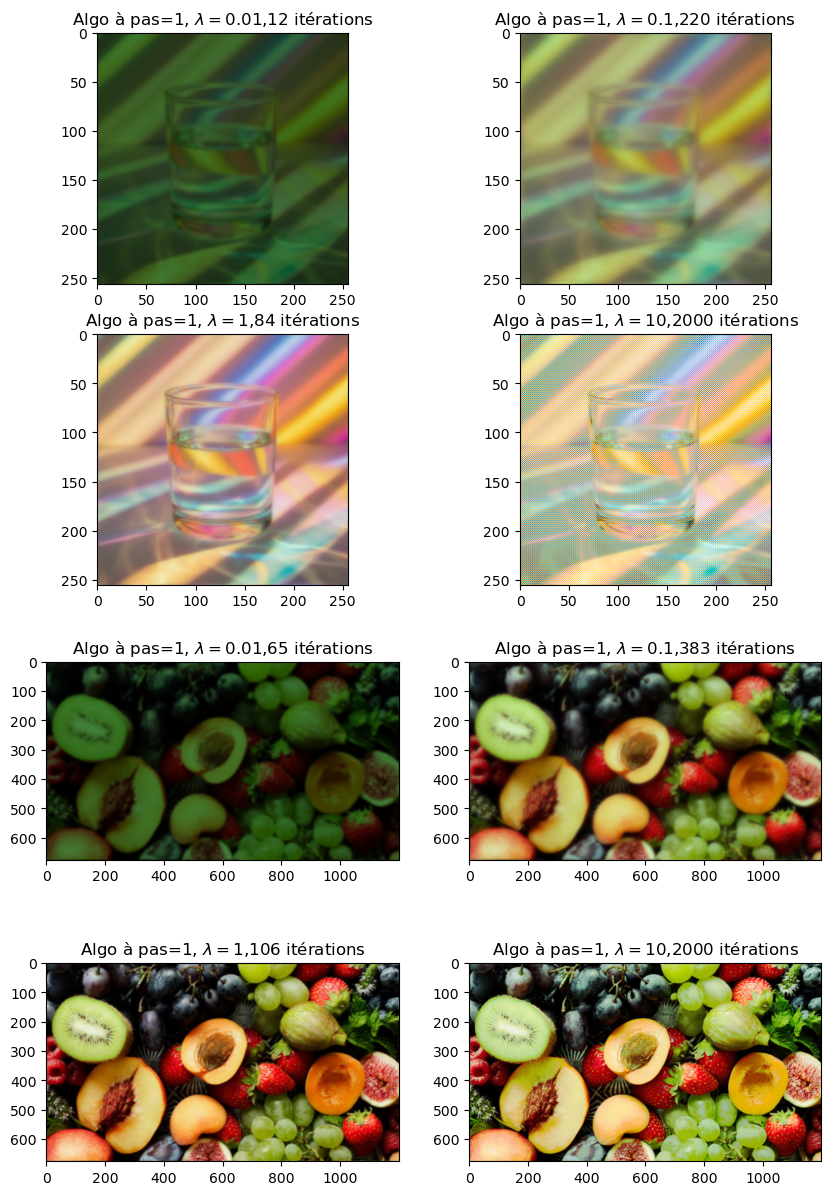

In [24]:
fig,ax=plt.subplots(4,2,figsize=(10,15))
ax[0,0].imshow(U_proj[0][0])
ax[0,0].set_title("Algo à pas=1, $\lambda=0.01$,%i itérations"%U_proj[0][1])
ax[0,1].imshow(U_proj[1][0])
ax[0,1].set_title("Algo à pas=1, $\lambda=0.1$,%i itérations"%U_proj[1][1])
ax[1,0].imshow(U_proj[2][0])
ax[1,0].set_title("Algo à pas=1, $\lambda=1$,%i itérations"%U_proj[2][1])
ax[1,1].imshow(U_proj[3][0])
ax[1,1].set_title("Algo à pas=1, $\lambda=10$,%i itérations"%U_proj[3][1])

ax[2,0].imshow(U_proj[4][0])
ax[2,0].set_title("Algo à pas=1, $\lambda=0.01$,%i itérations"%U_proj[4][1])
ax[2,1].imshow(U_proj[5][0])
ax[2,1].set_title("Algo à pas=1, $\lambda=0.1$,%i itérations"%U_proj[5][1])
ax[3,0].imshow(U_proj[6][0])
ax[3,0].set_title("Algo à pas=1, $\lambda=1$,%i itérations"%U_proj[6][1])
ax[3,1].imshow(U_proj[7][0])
ax[3,1].set_title("Algo à pas=1, $\lambda=10$,%i itérations"%U_proj[7][1])

La deuxième méthode est de simplement prendre un pas plus petit. On prendra finalement un pas de 0.1 qui semble assez efficace et stable

In [12]:
w = mpimg.imread("glass.png")[:,:,:3]
mask = np.zeros(np.shape(w))
mask[1::2, 1::2, 0] = 1.0  
mask[0::2, 0::2, 2] = 1.0  
mask[0::2, 1::2, 1] = 1.0  
mask[1::2, 0::2, 1] = 1.0 
U=[]
eps=.1
Nbiter=2000
v=bayer(w,0)

for L in [0.01,0.1,1,10]:
        u=de_ba(v,Nbiter,eps,.1,L)
        U.append(u)

w = mpimg.imread("test.png")[:,:,:3]
mask = np.zeros(np.shape(w))
mask[1::2, 1::2, 0] = 1.0  
mask[0::2, 0::2, 2] = 1.0  
mask[0::2, 1::2, 1] = 1.0  
mask[1::2, 0::2, 1] = 1.0 
v=bayer(w,0)

for L in [0.01,0.1,1,10]:
        u=de_ba(v,Nbiter,eps,.1,L)
        U.append(u)

In [13]:
for u in U:
    print(np.max(u[0]),np.min(u[0]))

0.518192107089943 0.06036403711163583
0.9048640568532007 0.1475756285544783
0.9911596517311182 0.09319619864364734
541.5744320344915 -0.04453477550612958
0.7989645456670527 0.002625102326536758
0.9579563233967963 0.0006294958462449952
0.9956194853751956 1.9824948909502723e-06
649.5716794981435 -0.39840308804649427


Text(0.5, 1.0, 'Algo à pas=0.1, $\\lambda=10$,2000 itérations')

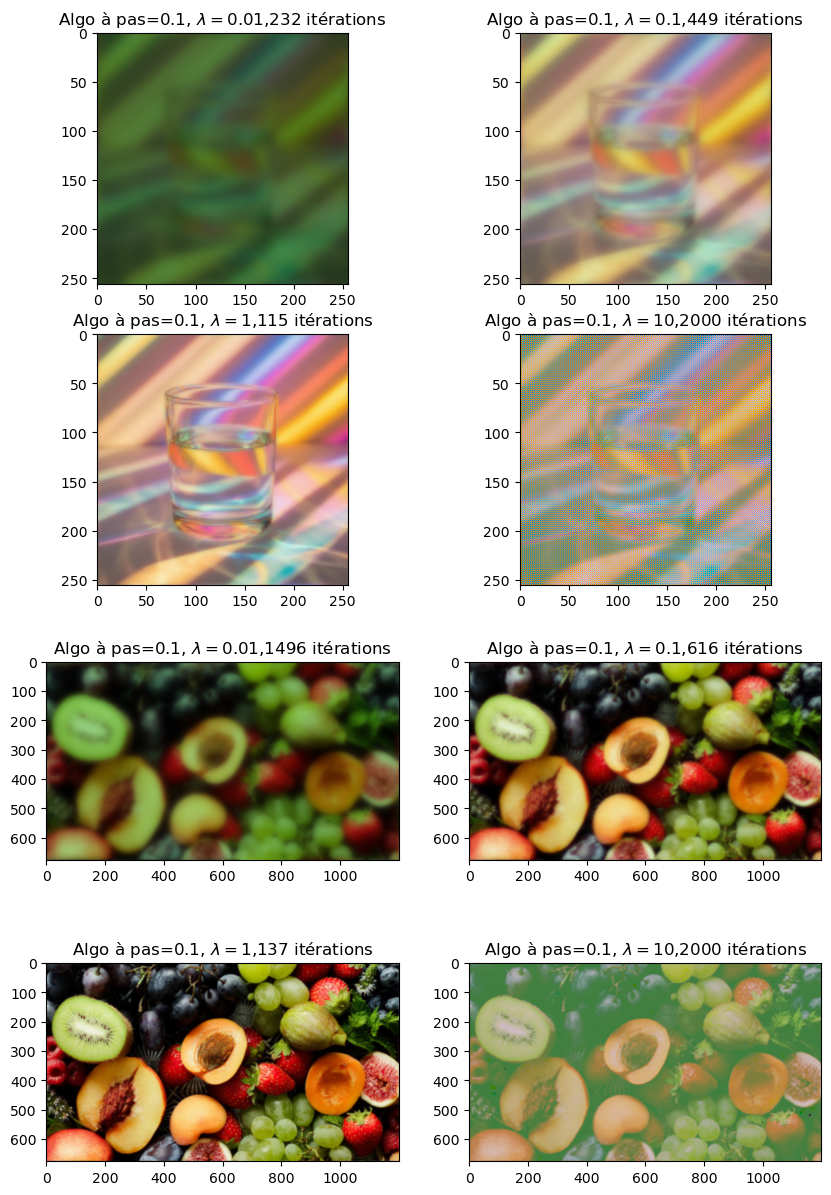

In [23]:
fig,ax=plt.subplots(4,2,figsize=(10,15))
ax[0,0].imshow(U[0][0])
ax[0,0].set_title("Algo à pas=0.1, $\lambda=0.01$,%i itérations"%U[0][1])
ax[0,1].imshow(U[1][0])
ax[0,1].set_title("Algo à pas=0.1, $\lambda=0.1$,%i itérations"%U[1][1])
ax[1,0].imshow(U[2][0])
ax[1,0].set_title("Algo à pas=0.1, $\lambda=1$,%i itérations"%U[2][1])
ax[1,1].imshow(np.maximum(np.minimum(U[3][0],1),0))
ax[1,1].set_title("Algo à pas=0.1, $\lambda=10$,%i itérations"%U[3][1])

ax[2,0].imshow(U[4][0])
ax[2,0].set_title("Algo à pas=0.1, $\lambda=0.01$,%i itérations"%U[4][1])
ax[2,1].imshow(U[5][0])
ax[2,1].set_title("Algo à pas=0.1, $\lambda=0.1$,%i itérations"%U[5][1])
ax[3,0].imshow(U[6][0])
ax[3,0].set_title("Algo à pas=0.1, $\lambda=1$,%i itérations"%U[6][1])
ax[3,1].imshow(np.maximum(np.minimum(U[7][0],1),0))
ax[3,1].set_title("Algo à pas=0.1, $\lambda=10$,%i itérations"%U[7][1])

In [27]:

plt.imsave("fruit tr.png",np.maximum(np.minimum(U[7][0],1),0))

On voit que pour ces 2 méthodes, on ne trouve pas de convergence pour $\lambda=10$. Pour améliorer notre algorithme, nous allons mettre au point un pas de plus grande descente par dichotomie.

In [ ]:

def de_ba_di(v,Nbiter,eps_d,eps,L):
    beta = 1
    out=bayer(v.copy(),1)
    it=0
    result=[Obj(out,L,beta,v)]
    ca=True
    while ca and it<Nbiter:
        it+=1

        d = grad_Obj(out,L,beta,v)
        a,b=0.0,1.0
        while b-a>eps_d:
            m1=a+(b-a)/3
            m2=b-(b-a)/3

            f1=Obj(out-m1*d,L,beta,v)
            f2=Obj(out-m2*d,L,beta,v)

            if f1<=f2:
                b=m2
            else:
                a=m1
        pas=(a+b)/2

        ca=abs(Obj(out,L,beta,v)-Obj(out - pas * d,L,beta,v))>eps
        out = out - pas * d
        result.append(Obj(out,L,beta,v))
    return out,it,result


In [29]:
w = mpimg.imread("glass.png")[:,:,:3]
mask = np.zeros(np.shape(w))
mask[1::2, 1::2, 0] = 1.0  
mask[0::2, 0::2, 2] = 1.0  
mask[0::2, 1::2, 1] = 1.0  
mask[1::2, 0::2, 1] = 1.0 
U_di=[]
eps=.1
Nbiter=2000
eps_d=10e-6

v=bayer(w,0)
for L in [10,50,100,500]:
       u=de_ba_di(v,Nbiter,eps_d,eps,L)
       U_di.append(u)


w = mpimg.imread("test.png")[:,:,:3]
mask = np.zeros(np.shape(w))
mask[1::2, 1::2, 0] = 1.0  
mask[0::2, 0::2, 2] = 1.0  
mask[0::2, 1::2, 1] = 1.0  
mask[1::2, 0::2, 1] = 1.0 
v=bayer(w,0)

for L in [10,50,100,500]:
       u=de_ba_di(v,Nbiter,eps_d,eps,L)
       U_di.append(u)

On remarque ici que les minimiseurs trouvé sorte de $[0.1]^{3(N\times M)}$ ce qui peut poser problème. En regardant qualitativement les min et max on remarque que ce dépassement est de l'ordre de l'epsilon machine, on fera donc juste une projection pour resoudre le problème sans trop modifier ce minimiseur.

In [36]:
for u in U_di:
    print(np.max(u[0]),np.min(u[0]))

0.9992026520342011 0.021029425056305312
0.9996465925843223 0.005837056244272244
0.9997788274687138 0.0029508206381244455
0.9999028566347999 0.0005853567069328952
0.9996212131512994 -1.9260329138038602e-07
0.999843234800926 -6.984811281971486e-11
0.9998992326893154 2.0761190574753222e-16
0.9999517883838411 -1.3821854285565783e-18


Text(0.5, 1.0, '$\\lambda=500$,1955 itérations')

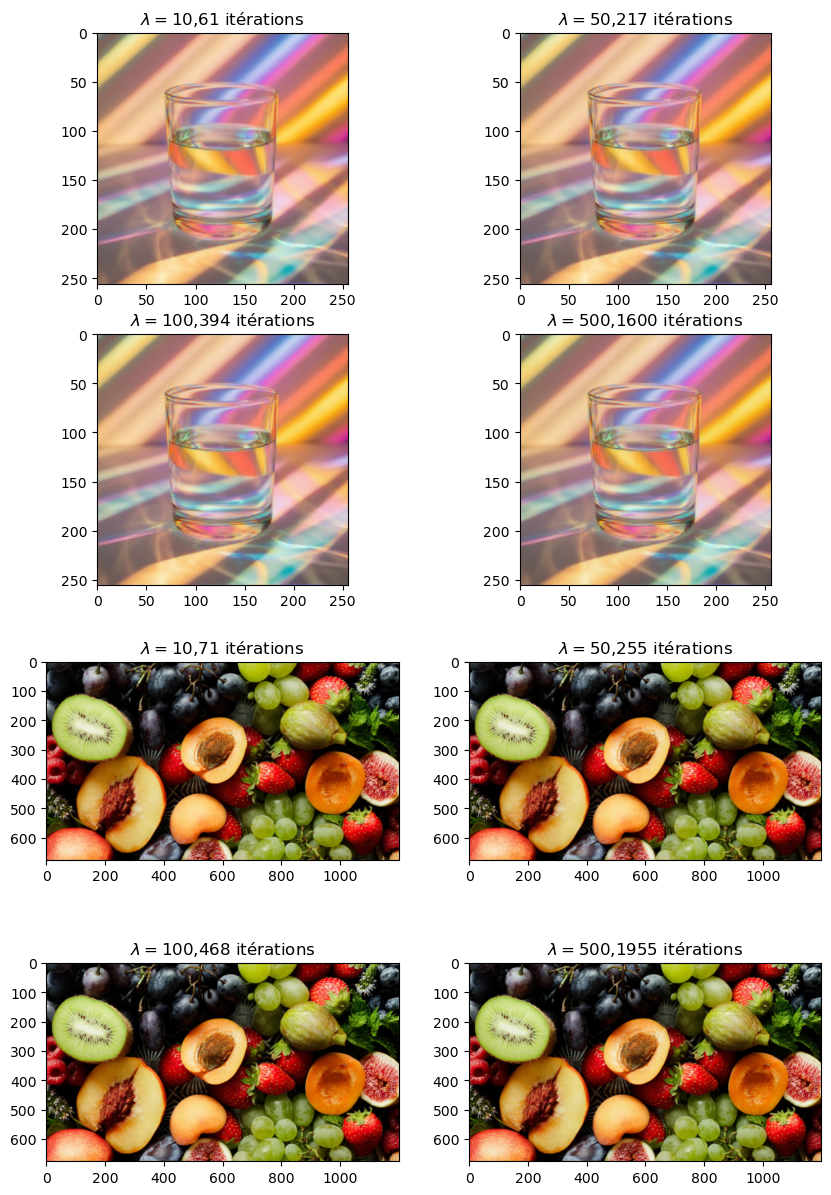

In [39]:
fig,ax=plt.subplots(4,2,figsize=(10,15))
ax[0,0].imshow(np.maximum(np.minimum(U_di[0][0],1),0))
ax[0,0].set_title("$\lambda=10$,%i itérations"%U_di[0][1])
ax[0,1].imshow(np.maximum(np.minimum(U_di[1][0],1),0))
ax[0,1].set_title("$\lambda=50$,%i itérations"%U_di[1][1])
ax[1,0].imshow(np.maximum(np.minimum(U_di[2][0],1),0))
ax[1,0].set_title("$\lambda=100$,%i itérations"%U_di[2][1])
ax[1,1].imshow(np.maximum(np.minimum(U_di[3][0],1),0))
ax[1,1].set_title("$\lambda=500$,%i itérations"%U_di[3][1])

ax[2,0].imshow(np.maximum(np.minimum(U_di[4][0],1),0))
ax[2,0].set_title("$\lambda=10$,%i itérations"%U_di[4][1])
ax[2,1].imshow(np.maximum(np.minimum(U_di[5][0],1),0))
ax[2,1].set_title("$\lambda=50$,%i itérations"%U_di[5][1])
ax[3,0].imshow(np.maximum(np.minimum(U_di[6][0],1),0))
ax[3,0].set_title("$\lambda=100$,%i itérations"%U_di[6][1])
ax[3,1].imshow(np.maximum(np.minimum(U_di[7][0],1),0))
ax[3,1].set_title("$\lambda=500$,%i itérations"%U_di[7][1])

On peut voir que l'algorithme est TRES long même avec des petite itérations, cela est dû au très grand nombre d'appel de la fonction objectif par la dichotomie. Pour régler ce problème nous allons utiliser la condition d'Armijo.

In [31]:


def de_ba_armi(v,tmax,b,sigma,Nbiter,eps,L):
    beta = 1
    out=bayer(v.copy(),1)
    it=0
    result=[Obj(out,L,beta,v)]
    ca=True
    while ca and it<Nbiter:
        it+=1

        d = grad_Obj(out,L,beta,v)
        i=1

        while (Obj(out,L,beta,v)-Obj(out-tmax*b**i*d,L,beta,v))<sigma*tmax*b**i*np.linalg.norm(d)**2:
            i+=1
        ca=abs(Obj(out,L,beta,v)-Obj(out - tmax*b**i * d,L,beta,v))>eps
        out = out - tmax*b**i * d
        result.append(Obj(out,L,beta,v))
    return out,it,result



In [32]:
w = mpimg.imread("glass.png")[:,:,:3]
mask = np.zeros(np.shape(w))
mask[1::2, 1::2, 0] = 1.0  
mask[0::2, 0::2, 2] = 1.0  
mask[0::2, 1::2, 1] = 1.0  
mask[1::2, 0::2, 1] = 1.0 
U_armi=[]
eps=.1
Nbiter=2000
tmax=.5
b=.5
sigma=.5

v=bayer(w,0)
for L in [10,50,100,500]:
       u=de_ba_armi(v,tmax,b,sigma,Nbiter,eps,L)
       U_armi.append(u)


w = mpimg.imread("test.png")[:,:,:3]
mask = np.zeros(np.shape(w))
mask[1::2, 1::2, 0] = 1.0  
mask[0::2, 0::2, 2] = 1.0  
mask[0::2, 1::2, 1] = 1.0  
mask[1::2, 0::2, 1] = 1.0 
v=bayer(w,0)
for L in [10,50,100,500]:
        u=de_ba_armi(v,tmax,b,sigma,Nbiter,eps,L)
        U_armi.append(u)

Text(0.5, 1.0, '$\\lambda=10$,145 itérations')

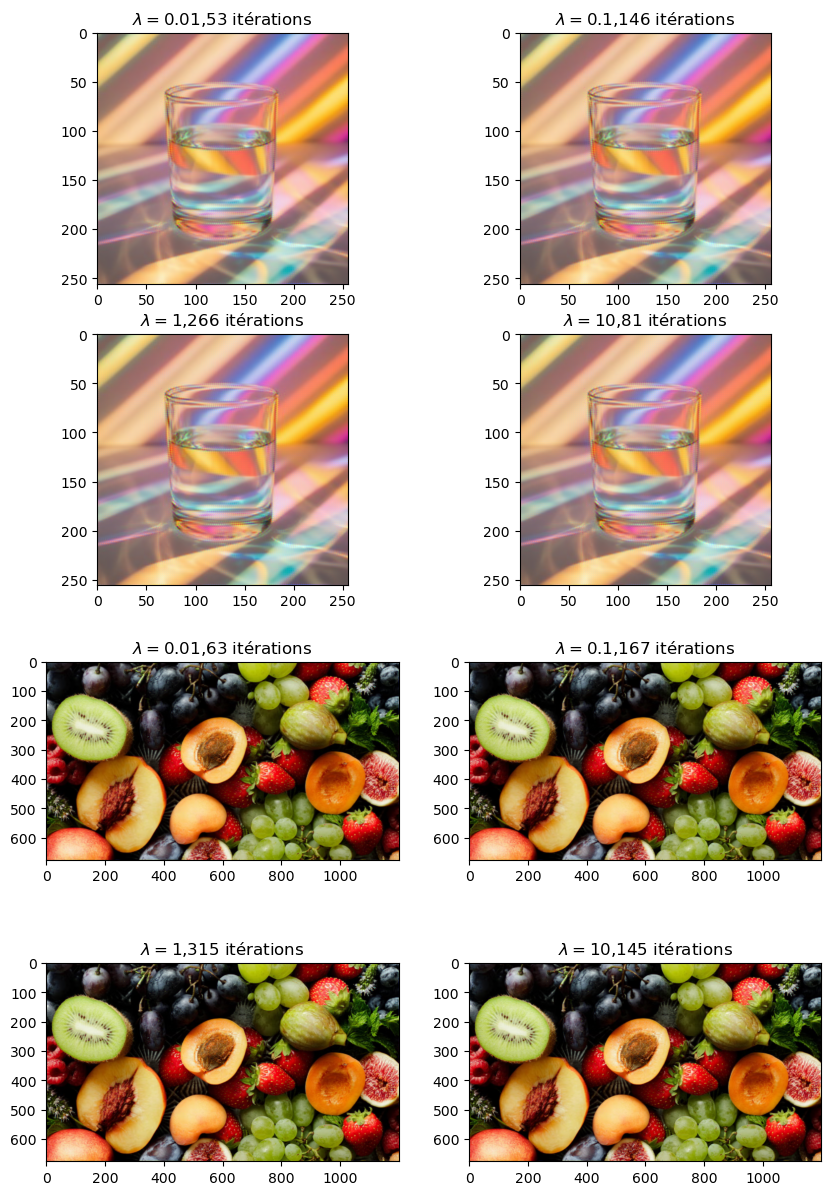

In [43]:
fig,ax=plt.subplots(4,2,figsize=(10,15))
ax[0,0].imshow(U_armi[0][0])
ax[0,0].set_title("$\lambda=0.01$,%i itérations"%U_armi[0][1])
ax[0,1].imshow(U_armi[1][0])
ax[0,1].set_title("$\lambda=0.1$,%i itérations"%U_armi[1][1])
ax[1,0].imshow(U_armi[2][0])
ax[1,0].set_title("$\lambda=1$,%i itérations"%U_armi[2][1])
ax[1,1].imshow(U_armi[3][0])
ax[1,1].set_title("$\lambda=10$,%i itérations"%U_armi[3][1])

ax[2,0].imshow(U_armi[4][0])
ax[2,0].set_title("$\lambda=0.01$,%i itérations"%U_armi[4][1])
ax[2,1].imshow(U_armi[5][0])
ax[2,1].set_title("$\lambda=0.1$,%i itérations"%U_armi[5][1])
ax[3,0].imshow(U_armi[6][0])
ax[3,0].set_title("$\lambda=1$,%i itérations"%U_armi[6][1])
ax[3,1].imshow(U_armi[7][0])
ax[3,1].set_title("$\lambda=10$,%i itérations"%U_armi[7][1])

Pour étuider la convergence des algorithmes de Armijo et pas de plus grande descente, on peut tracer $E(w_k)$ en fonction de k

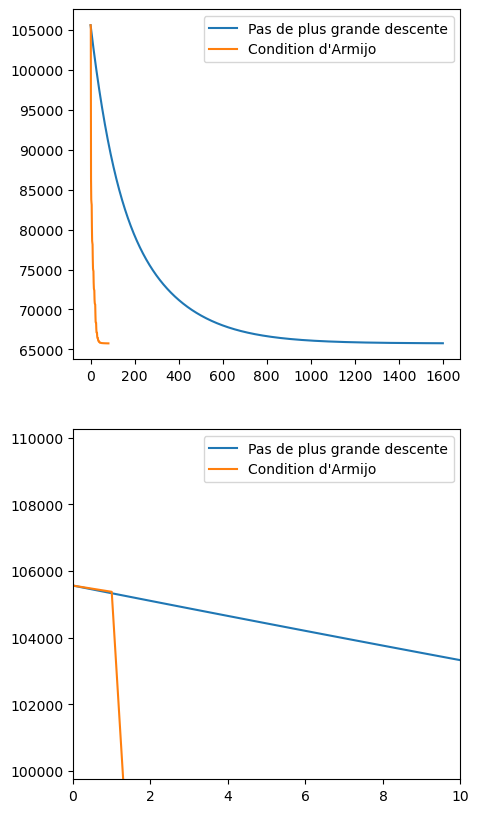

In [58]:
fig,ax=plt.subplots(2,figsize=(5,10))
ax[0].plot(U_di[3][2],label="Pas de plus grande descente")
ax[0].plot(U_armi[3][2],label="Condition d'Armijo")
ax[0].legend()
ax[1].plot(U_di[3][2],label="Pas de plus grande descente")
ax[1].plot(U_armi[3][2],label="Condition d'Armijo")
ax[1].set_ylim(105000,105000)
ax[1].set_xlim(0,10)
ax[1].legend()


Pour visualiser l'efficacité de nos méthode, on peut regarder la difference entre leurs minimiseurs et l'image d'origine $e=|w-w_\infty|$. e devrait ainsi être une image noir si l'erreur est petite, et la moyenne de e, $\langle e \rangle$ permet d'estimer la méthode. On regardera ici seulement la méthode d'Armijo car c'est la plus éfficace.

Text(0.5, 1.0, '$\\lambda=500$ Erreur:0.013301')

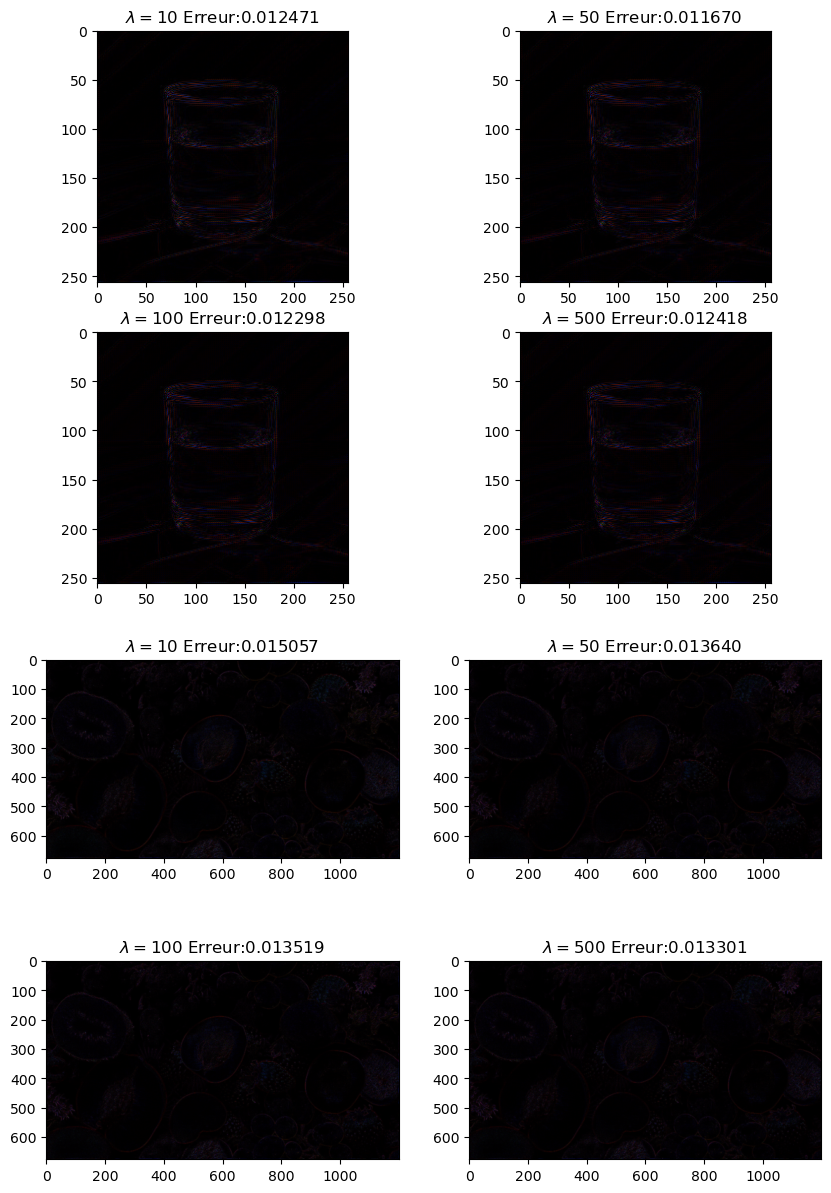

In [62]:
w = mpimg.imread("glass.png")[:,:,:3]
fig,ax=plt.subplots(4,2,figsize=(10,15))
ax[0,0].imshow(abs(w-U_armi[0][0]))
ax[0,0].set_title("$\lambda=10$ Erreur:%f"%np.mean(abs(w-U_armi[0][0])))
ax[0,1].imshow(abs(w-U_armi[1][0]))
ax[0,1].set_title("$\lambda=50$ Erreur:%f"%np.mean(abs(w-U_armi[1][0])))
ax[1,0].imshow(abs(w-U_armi[2][0]))
ax[1,0].set_title("$\lambda=100$ Erreur:%f"%np.mean(abs(w-U_armi[2][0])))
ax[1,1].imshow(abs(w-U_armi[3][0]))
ax[1,1].set_title("$\lambda=500$ Erreur:%f"%np.mean(abs(w-U_armi[3][0])))

w = mpimg.imread("test.png")[:,:,:3]
ax[2,0].imshow(abs(w-U_armi[4][0]))
ax[2,0].set_title("$\lambda=10$ Erreur:%f"%np.mean(abs(w-U_armi[4][0])))
ax[2,1].imshow(abs(w-U_armi[5][0]))
ax[2,1].set_title("$\lambda=50$ Erreur:%f"%np.mean(abs(w-U_armi[5][0])))
ax[3,0].imshow(abs(w-U_armi[6][0]))
ax[3,0].set_title("$\lambda=100$ Erreur:%f"%np.mean(abs(w-U_armi[6][0])))
ax[3,1].imshow(abs(w-U_armi[7][0]))
ax[3,1].set_title("$\lambda=500$ Erreur:%f"%np.mean(abs(w-U_armi[7][0])))

Ainsi pour l'image de verre le $\lambda$ le plus éfficace est à 50

Text(0.5, 1.0, '$\\lambda=50$ Erreur:0.011670')

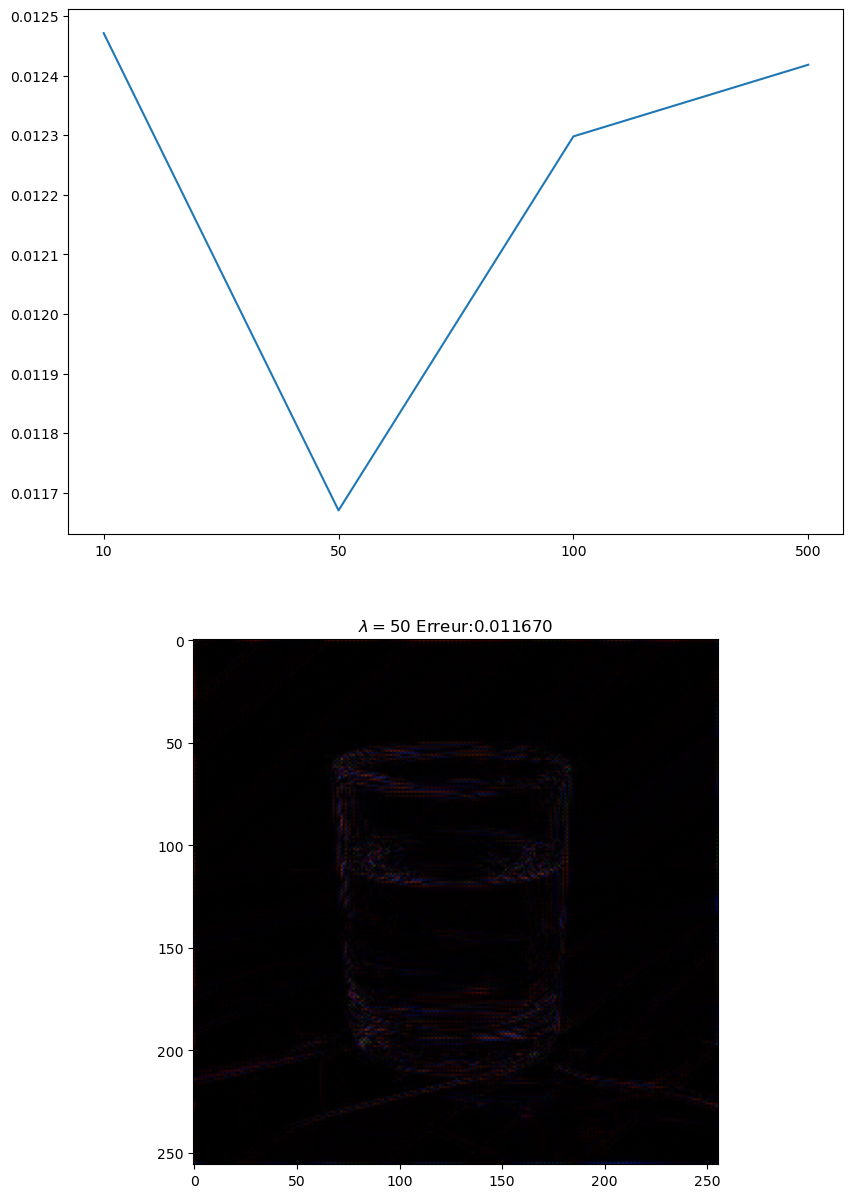

In [77]:
w = mpimg.imread("glass.png")[:,:,:3]
fig, ax=plt.subplots(2,figsize=(10,15))
ax[0].plot([0,1,2,3],[np.mean(abs(U_armi[k][0]-w)) for k in [0,1,2,3]])
ax[0].set_xticks([0,1,2,3], labels=[10,50,100,500])

ax[1].imshow(abs(w-U_armi[1][0]))
ax[1].set_title("$\lambda=50$ Erreur:%f"%np.mean(abs(w-U_armi[1][0])))

Et pour l'image de fruit, le plus éfficace est au dela de $\lambda=500$

Text(0.5, 1.0, '$\\lambda=500$ Erreur:0.013301')

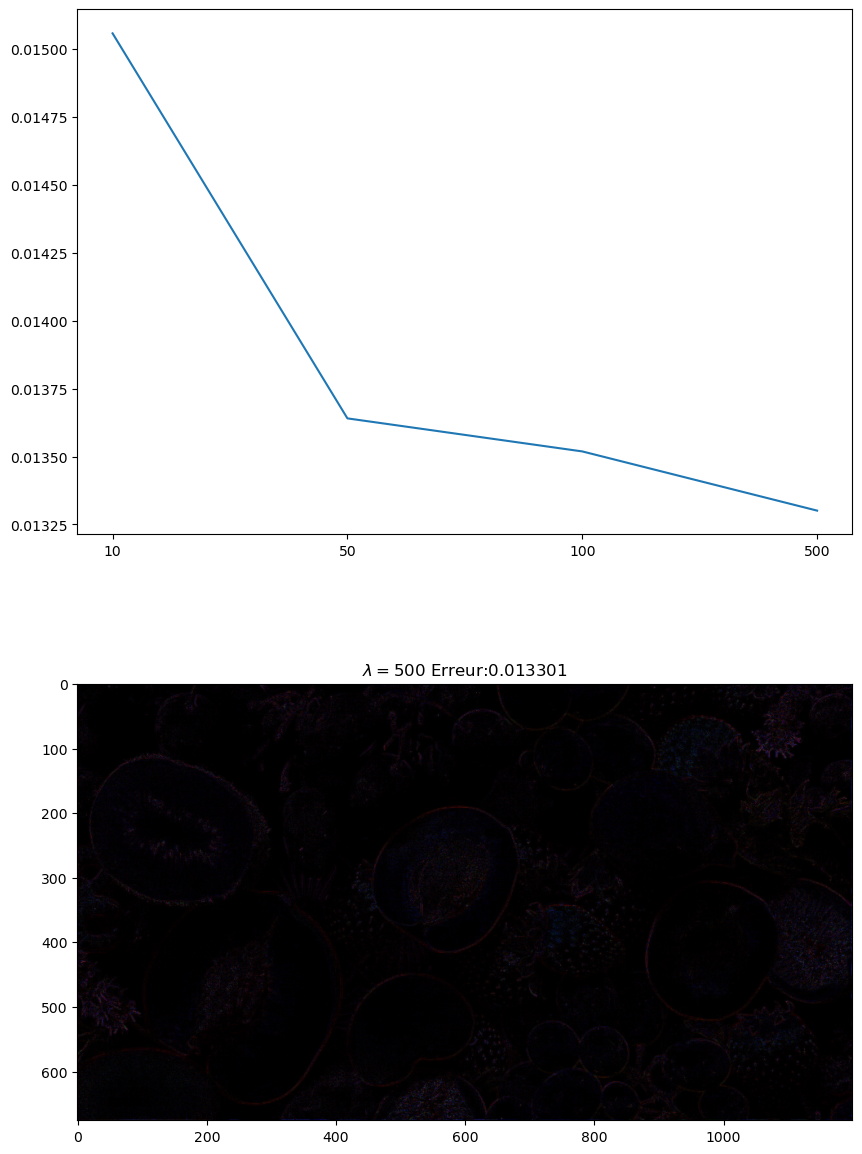

In [80]:
w = mpimg.imread("test.png")[:,:,:3]
fig, ax=plt.subplots(2,figsize=(10,15))
ax[0].plot([0,1,2,3],[np.mean(abs(U_armi[k][0]-w)) for k in [4,5,6,7]])
ax[0].set_xticks([0,1,2,3], labels=[10,50,100,500])

ax[1].imshow(abs(w-U_armi[7][0]))
ax[1].set_title("$\lambda=500$ Erreur:%f"%np.mean(abs(w-U_armi[7][0])))